# Modélisation XGBoost — scénario météo parfaite


In [2]:
from pathlib import Path
import sys

sys.path.append(str(Path("..") / "src"))

from models.features_xgboost import (
    charger_dataset_final,
    construire_table_horizons,
    split_train_val_test,
    verifier_table,
)


## 2. Construction de la table empilée (jour de prévision × horizon)

In [ ]:
table = construire_table_horizons(df, scenario="parfait")
print(table.shape)
table.columns
table.head(30)


(93697, 39)


,date_prevision,horizon_h,timestamp_cible_paris,timestamp_cible_utc,cible_consommation_mw,conso_J_moins_7,conso_J_moins_365,conso_J_moins_366,conso_dernieres_24h_moyenne,conso_dernieres_24h_min,...,meteo_parfaite_precip_1h_mm,meteo_parfaite_temperature_c_pondere_pop,meteo_parfaite_temperature_point_rosee_c_pondere_pop,meteo_parfaite_humidite_pct_pondere_pop,meteo_parfaite_vent_direction_deg_pondere_pop,meteo_parfaite_vent_vitesse_ms_pondere_pop,meteo_parfaite_nebulosite_pondere_pop,meteo_parfaite_precip_1h_mm_pondere_pop,degres_sous_15,degres_au_dessus_22
0,2016-01-01 00:00:00+01:00,0,2016-01-02 00:00:00+01:00,2016-01-01 23:00:00+00:00,56405.5,NaN,NaN,NaN,52047.500000,48761.0,...,0.253846,8.492207,6.622066,88.201711,138.380196,3.912592,97.333435,0.177414,6.507793,0.0
1,2016-01-01 00:00:00+01:00,1,2016-01-02 01:00:00+01:00,2016-01-02 00:00:00+00:00,52481.0,NaN,NaN,NaN,52047.500000,48761.0,...,0.107692,8.685147,6.656785,87.307457,140.718215,3.541259,96.245416,0.124847,6.314853,0.0
2,2016-01-01 00:00:00+01:00,2,2016-01-02 02:00:00+01:00,2016-01-02 01:00:00+00:00,51202.5,NaN,NaN,NaN,52047.500000,48761.0,...,0.107692,8.685147,6.656785,87.307457,140.718215,3.541259,95.809142,0.124847,6.314853,0.0
3,2016-01-01 00:00:00+01:00,3,2016-01-02 03:00:00+01:00,2016-01-02 02:00:00+00:00,48489.5,NaN,NaN,NaN,52047.500000,48761.0,...,0.107692,8.685147,6.656785,87.307457,140.718215,3.541259,95.809142,0.124847,6.314853,0.0
4,2016-01-01 00:00:00+01:00,4,2016-01-02 04:00:00+01:00,2016-01-02 03:00:00+00:00,46772.0,NaN,NaN,NaN,52047.500000,48761.0,...,0.053846,8.796057,7.004859,88.712408,172.487775,3.863081,95.904645,0.002384,6.203943,0.0
5,2016-01-01 00:00:00+01:00,5,2016-01-02 05:00:00+01:00,2016-01-02 04:00:00+00:00,46914.0,NaN,NaN,NaN,52047.500000,48761.0,...,0.053846,8.796057,7.004859,88.712408,172.487775,3.863081,95.904645,0.002384,6.203943,0.0
6,2016-01-01 00:00:00+01:00,6,2016-01-02 06:00:00+01:00,2016-01-02 05:00:00+00:00,48281.0,NaN,NaN,NaN,52047.500000,48761.0,...,0.053846,8.796057,7.004859,88.712408,172.487775,3.863081,95.904645,0.002384,6.203943,0.0
7,2016-01-01 00:00:00+01:00,7,2016-01-02 07:00:00+01:00,2016-01-02 06:00:00+00:00,49961.0,NaN,NaN,NaN,52047.500000,48761.0,...,0.215385,8.834413,6.901711,88.214548,177.955379,3.972800,94.705073,0.207793,6.165587,0.0
8,2016-01-01 00:00:00+01:00,8,2016-01-02 08:00:00+01:00,2016-01-02 07:00:00+00:00,51916.5,NaN,NaN,NaN,52047.500000,48761.0,...,0.215385,8.834413,6.901711,88.214548,177.955379,3.972800,94.705073,0.207793,6.165587,0.0
9,2016-01-01 00:00:00+01:00,9,2016-01-02 09:00:00+01:00,2016-01-02 08:00:00+00:00,53774.5,NaN,NaN,NaN,52047.500000,48761.0,...,0.215385,8.834413,6.901711,88.214548,177.955379,3.972800,94.705073,0.207793,6.165587,0.0


## 3. Vérifications de bon sens

- chaque jour doit avoir 23, 24 ou 25 lignes (jamais autre chose) ;
- la cible ne doit jamais être manquante.

In [4]:
resultats = verifier_table(table)
for cle, valeur in resultats.items():
    print(f"{cle} :", valeur)


n_lignes : 93697
n_jours_prevision : 3905
repartition_nb_horizons_par_jour : {24: 3883, 23: 11, 25: 10, 2: 1}
jours_hors_23_24_25 : {Timestamp('2026-09-30 00:00:00+0200', tz='Europe/Paris'): 2}
cible_manquante : 0


## 4. Aperçu des valeurs manquantes dans les features

Normal d'avoir des NaN sur `conso_J_moins_365`/`366` au tout début de l'historique (pas encore un an de recul) — à gérer avant l'entraînement (dropna ou imputation).

In [5]:
table.isna().sum().sort_values(ascending=False).head(15)


conso_J_moins_366              8713
conso_J_moins_365              8689
conso_J_moins_7                 145
conso_J_moins_1_meme_heure       10
horizon_h                         0
timestamp_cible_paris             0
date_prevision                    0
timestamp_cible_utc               0
cible_consommation_mw             0
conso_dernieres_24h_min           0
conso_dernieres_24h_moyenne       0
heure_sin                         0
heure_cos                         0
jour_annee_sin                    0
conso_dernieres_24h_max           0
dtype: int64

## Prochaine étape

Entraînement du modèle XGBoost sur `train`, évaluation sur `val` (globalement et par `horizon_h`), comparaison aux baselines.

In [ ]:
from models.entrainer_xgboost import (
    charger_splits,
    encoder_categorielles,
    separer_x_y,
    entrainer_xgboost,
    evaluer,

)


## 7.1 Chargement des splits déjà sauvegardés

In [5]:
train, val, test = charger_splits()
print(train.shape, val.shape, test.shape)


(69744, 39) (8736, 39) (15217, 39)


## 7.2 Encodage catégoriel + séparation X / y

La liste des colonnes de features est fixée sur `train`, puis réutilisée telle quelle pour `val`/`test` (mêmes colonnes, même ordre).

In [6]:
train, val, test = encoder_categorielles(train, val, test)

X_train, y_train, colonnes_features = separer_x_y(train)
X_val, y_val, _ = separer_x_y(val, colonnes_features)
X_test, y_test, _ = separer_x_y(test, colonnes_features)

print(f"{len(colonnes_features)} features :")
print(colonnes_features)


38 features :
['horizon_h', 'conso_J_moins_7', 'conso_J_moins_365', 'conso_J_moins_366', 'conso_dernieres_24h_moyenne', 'conso_dernieres_24h_min', 'conso_dernieres_24h_max', 'heure_sin', 'heure_cos', 'jour_annee_sin', 'jour_annee_cos', 'conso_J_moins_1_meme_heure', 'jour_semaine', 'mois', 'weekend', 'ferie', 'vacances', 'confinement_numero', 'meteo_parfaite_temperature_c', 'meteo_parfaite_temperature_point_rosee_c', 'meteo_parfaite_humidite_pct', 'meteo_parfaite_vent_direction_deg', 'meteo_parfaite_vent_vitesse_ms', 'meteo_parfaite_nebulosite', 'meteo_parfaite_precip_1h_mm', 'meteo_parfaite_temperature_c_pondere_pop', 'meteo_parfaite_temperature_point_rosee_c_pondere_pop', 'meteo_parfaite_humidite_pct_pondere_pop', 'meteo_parfaite_vent_direction_deg_pondere_pop', 'meteo_parfaite_vent_vitesse_ms_pondere_pop', 'meteo_parfaite_nebulosite_pondere_pop', 'meteo_parfaite_precip_1h_mm_pondere_pop', 'degres_sous_15', 'degres_au_dessus_22', 'saison_Automne', 'saison_Hiver', 'saison_Printemps', '

## 7.3 Entraînement (avec early stopping sur la validation)

In [7]:
modele = entrainer_xgboost(X_train, y_train, X_val, y_val)


[0]	validation_0-mae:9219.03714	validation_1-mae:8164.99987
[50]	validation_0-mae:3070.99825	validation_1-mae:2708.71998
[100]	validation_0-mae:1773.62536	validation_1-mae:1605.08132
[150]	validation_0-mae:1397.90897	validation_1-mae:1338.66040
[200]	validation_0-mae:1249.78053	validation_1-mae:1262.41358
[250]	validation_0-mae:1162.05554	validation_1-mae:1222.22146
[300]	validation_0-mae:1097.70885	validation_1-mae:1190.88306
[350]	validation_0-mae:1049.65345	validation_1-mae:1166.11255
[400]	validation_0-mae:1010.94483	validation_1-mae:1145.85980
[450]	validation_0-mae:976.79548	validation_1-mae:1125.47281
[500]	validation_0-mae:947.08131	validation_1-mae:1107.71925
[550]	validation_0-mae:921.85653	validation_1-mae:1093.49905
[600]	validation_0-mae:900.01076	validation_1-mae:1080.42398
[650]	validation_0-mae:880.35823	validation_1-mae:1069.65131
[700]	validation_0-mae:861.22264	validation_1-mae:1058.84870
[750]	validation_0-mae:841.02409	validation_1-mae:1047.70437
[800]	validation_0

## 7.4 Évaluation globale et par horizon (sur la validation)

In [8]:
resultats_val, pred_val = evaluer(modele, X_val, y_val, horizon_h=val["horizon_h"])

print("MAE  :", round(resultats_val["mae"], 1), "MW")
print("RMSE :", round(resultats_val["rmse"], 1), "MW")
print("MAPE :", round(resultats_val["mape"], 2), "%")

resultats_val["par_horizon"]


MAE  : 933.3 MW
RMSE : 1304.8 MW
MAPE : 1.79 %


,mae,rmse
horizon_h,,
0,689.722839,923.277163
1,684.458963,942.861035
2,665.177370,918.095413
3,662.386885,893.353395
4,668.469619,908.965874
5,712.089130,978.425213
6,843.840783,1193.693974
7,941.548243,1335.128231
8,983.712976,1403.778033


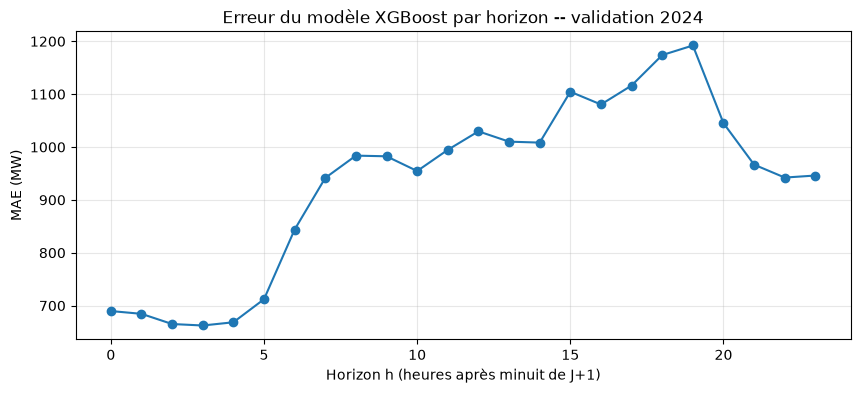

In [9]:
import matplotlib.pyplot as plt

resultats_val["par_horizon"]["mae"].plot(marker="o", figsize=(10, 4))
plt.xlabel("Horizon h (heures après minuit de J+1)")
plt.ylabel("MAE (MW)")
plt.title("Erreur du modèle XGBoost par horizon -- validation 2024")
plt.grid(alpha=.3)
plt.show()


L'erreur suit une forme en "W" :

- Horizons 0-5 (minuit-5h) : MAE la plus basse (~730-790 MW). Nuit = consommation stable et très prévisible.

- Horizons 6-9 (lever du jour, pointe du matin) : ça grimpe fort (jusqu'à 1115 MW à h8). Le réveil/démarrage de l'activité économique est le moment le plus variable de la journée , logique que ce soit le plus dur à prévoir.

- Horizons 10-14 (plateau de journée) : ça redescend (~1000-1050 MW). Plateau stable, comme dans l' EDA.

- Horizons 15-19 (fin d'après-midi → pointe du soir) : le pic d'erreur du modèle (jusqu'à 1227 MW à h18), exactement le moment de la pointe du soir que l' EDA identifiait comme le pic de conso de la journée. C'est le moment le plus dur à prévoir car le plus variable (dépend fortement du froid, des habitudes).

- Horizons 20-23 : ça redescend progressivement vers la stabilité nocturne.

C'est un signal de qualité, pas un problème : le modèle a plus de mal exactement là où la vraie consommation est elle-même la plus volatile (les rampes du matin et du soir)

## 7.5 Importance des features

In [10]:
(modele, colonnes_features, top_n=20)


conso_J_moins_1_meme_heure                              0.519134
conso_J_moins_7                                         0.171698
weekend                                                 0.063562
jour_semaine                                            0.037041
degres_sous_15                                          0.031875
conso_dernieres_24h_max                                 0.030628
meteo_parfaite_temperature_c_pondere_pop                0.028786
ferie                                                   0.021907
horizon_h                                               0.013170
meteo_parfaite_temperature_point_rosee_c_pondere_pop    0.011912
conso_dernieres_24h_moyenne                             0.007715
heure_cos                                               0.007637
heure_sin                                               0.006703
jour_annee_cos                                          0.006408
saison_Printemps                                        0.005521
meteo_parfaite_temperatur

## test


In [17]:
from models.entrainer_xgboost import charger_splits, encoder_categorielles, separer_x_y, entrainer_xgboost, evaluer

# Chargement (si pas déjà fait)
train, val, test = charger_splits()
train, val, test = encoder_categorielles(train, val, test)

X_train, y_train, colonnes_features = separer_x_y(train)
X_val, y_val, _ = separer_x_y(val, colonnes_features)
X_test, y_test, _ = separer_x_y(test, colonnes_features)

# Si le modèle est déjà entraîné en mémoire (variable `modele`), pas besoin de
# ré-entraîner -- sinon :
# modele = entrainer_xgboost(X_train, y_train, X_val, y_val)

# Évaluation sur TEST (jamais vu, ni entraînement ni early stopping)
resultats_test, pred_test = evaluer(modele, X_test, y_test, horizon_h=test["horizon_h"])

print(f"MAE  : {resultats_test['mae']:.1f} MW")
print(f"RMSE : {resultats_test['rmse']:.1f} MW")
print(f"MAPE : {resultats_test['mape']:.2f} %")

print("\n--- Comparaison train / val / test ---")
resultats_train, _ = evaluer(modele, X_train, y_train)
resultats_val, _ = evaluer(modele, X_val, y_val)
print(f"Train : MAE {resultats_train['mae']:.1f}")
print(f"Val   : MAE {resultats_val['mae']:.1f}")
print(f"Test  : MAE {resultats_test['mae']:.1f}")

MAE  : 957.0 MW
RMSE : 1278.0 MW
MAPE : 1.88 %

--- Comparaison train / val / test ---
Train : MAE 521.7
Val   : MAE 933.3
Test  : MAE 957.0


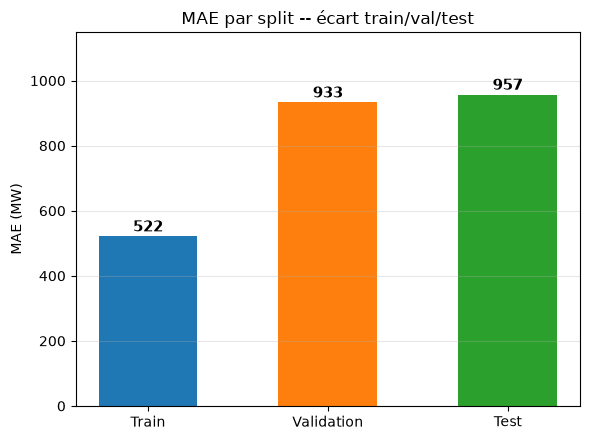

In [ ]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Graphique 1 : MAE train / val / test
# ------------------------------------------------------------------

splits = ["Train", "Validation", "Test"]
valeurs = [resultats_train["mae"], resultats_val["mae"], resultats_test["mae"]]
couleurs = ["#1f77b4", "#ff7f0e", "#2ca02c"]

fig, ax = plt.subplots(figsize=(6, 4.5))
barres = ax.bar(splits, valeurs, color=couleurs, width=0.55)

for barre, val in zip(barres, valeurs):
    ax.text(barre.get_x() + barre.get_width() / 2, val + 15,
            f"{val:.0f}", ha="center", fontsize=11, fontweight="bold")

ax.set_ylabel("MAE (MW)")
ax.set_title("MAE par split -- écart train/val/test")
ax.set_ylim(0, max(valeurs) * 1.2)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


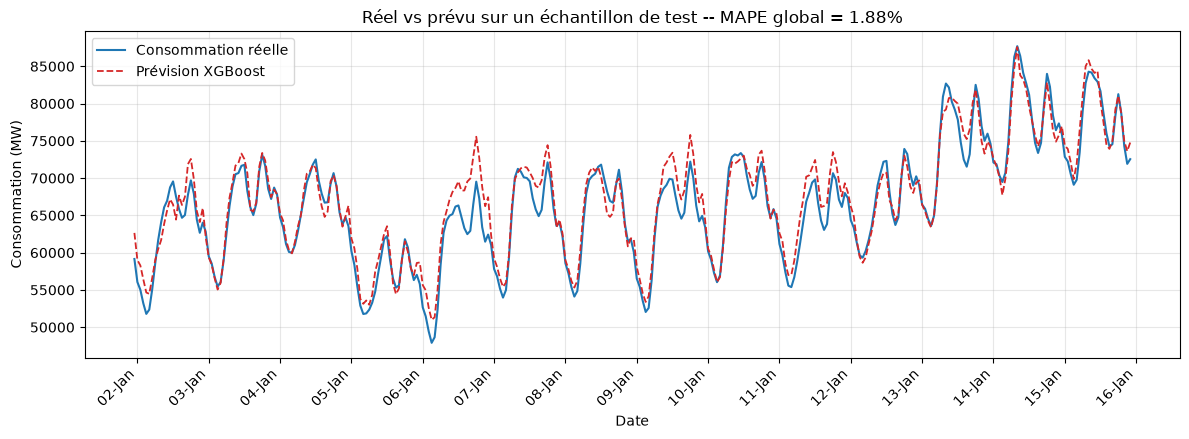

In [35]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Échantillon lisible : les 14 premiers jours (336h) du test, triés par date cible
echantillon = test.sort_values("timestamp_cible_paris").head(24 * 14).copy()

# Conversion explicite en datetime -- sans ça, DayLocator ne fonctionne pas
echantillon["timestamp_cible_paris"] = pd.to_datetime(echantillon["timestamp_cible_paris"], utc=True).dt.tz_convert("Europe/Paris")

X_echantillon, y_echantillon, _ = separer_x_y(echantillon, colonnes_features)
pred_echantillon = modele.predict(X_echantillon)

fig, ax = plt.subplots(figsize=(12, 4.5))

ax.plot(echantillon["timestamp_cible_paris"], y_echantillon,
        label="Consommation réelle", color="#1f77b4", linewidth=1.5)
ax.plot(echantillon["timestamp_cible_paris"], pred_echantillon,
        label="Prévision XGBoost", color="#d62728", linewidth=1.3, linestyle="--")

ax.set_xlabel("Date")
ax.set_ylabel("Consommation (MW)")
ax.set_title(f"Réel vs prévu sur un échantillon de test -- MAPE global = {resultats_test['mape']:.2f}%")
ax.legend()
ax.grid(alpha=0.3)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
fig.autofmt_xdate(rotation=45, ha="right")

plt.tight_layout()
plt.show()

Le modèle sur-estime légèrement certains pics (ex: le 6-7 janvier, la prévision dépasse nettement le réel — pic rouge à ~76 000 contre réel à ~68 000 MW). C'est cohérent avec ce qu'on avait vu dans la courbe par horizon : les heures de pointe (15h-19h) sont les plus dures à prédire, logique vu que ce sont les moments où le comportement humain (chauffage, activité) introduit le plus de variabilité non capturée par les lags.

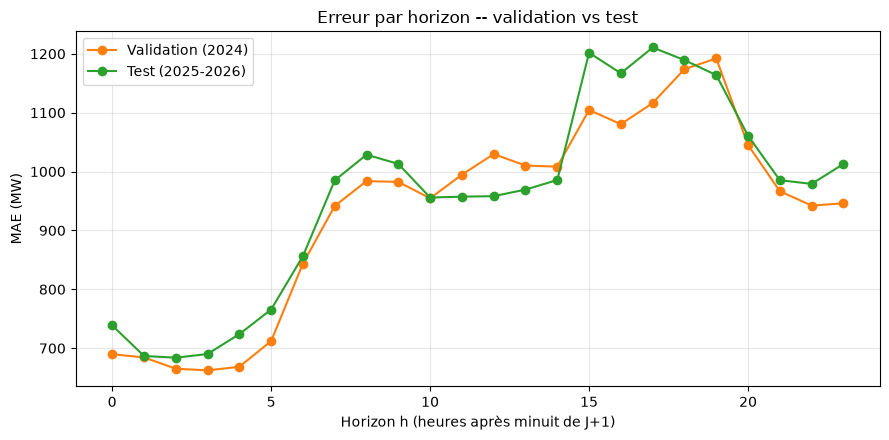

In [28]:
# Si pas déjà fait :
train, val, test = charger_splits()
train, val, test = encoder_categorielles(train, val, test)
# ------------------------------------------------------------------
# Graphique 2 : erreur par horizon -- validation vs test
# ------------------------------------------------------------------
resultats_val, _ = evaluer(modele, X_val, y_val, horizon_h=val["horizon_h"])

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(resultats_val["par_horizon"].index, resultats_val["par_horizon"]["mae"],
        marker="o", label="Validation (2024)", color="#ff7f0e")
ax.plot(resultats_test["par_horizon"].index, resultats_test["par_horizon"]["mae"],
        marker="o", label="Test (2025-2026)", color="#2ca02c")

ax.set_xlabel("Horizon h (heures après minuit de J+1)")
ax.set_ylabel("MAE (MW)")
ax.set_title("Erreur par horizon -- validation vs test")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Baseline 1 : persistance J-7 (même heure, semaine dernière)
mae_baseline_j7 = mean_absolute_error(test["cible_consommation_mw"], test["conso_J_moins_7"])
mape_baseline_j7 = np.mean(np.abs((test["cible_consommation_mw"] - test["conso_J_moins_7"]) / test["cible_consommation_mw"])) * 100

# Baseline 2 : persistance J-1 même heure (feature déjà dans ta table)
mae_baseline_j1 = mean_absolute_error(test["cible_consommation_mw"], test["conso_J_moins_1_meme_heure"])
mape_baseline_j1 = np.mean(np.abs((test["cible_consommation_mw"] - test["conso_J_moins_1_meme_heure"]) / test["cible_consommation_mw"])) * 100

print(f"Baseline J-7 : MAE {mae_baseline_j7:.1f} MW, MAPE {mape_baseline_j7:.2f}%")
print(f"Baseline J-1 : MAE {mae_baseline_j1:.1f} MW, MAPE {mape_baseline_j1:.2f}%")
print(f"XGBoost      : MAE {resultats_test['mae']:.1f} MW, MAPE {resultats_test['mape']:.2f}%")

gain_j7 = (mae_baseline_j7 - resultats_test['mae']) / mae_baseline_j7 * 100
gain_j1 = (mae_baseline_j1 - resultats_test['mae']) / mae_baseline_j1 * 100
print(f"\nGain XGBoost vs J-7 : {gain_j7:.1f}%")
print(f"Gain XGBoost vs J-1 : {gain_j1:.1f}%")

Baseline J-7 : MAE 3406.1 MW, MAPE 6.46%
Baseline J-1 : MAE 2997.3 MW, MAPE 6.07%
XGBoost      : MAE 957.0 MW, MAPE 1.88%

Gain XGBoost vs J-7 : 71.9%
Gain XGBoost vs J-1 : 68.1%


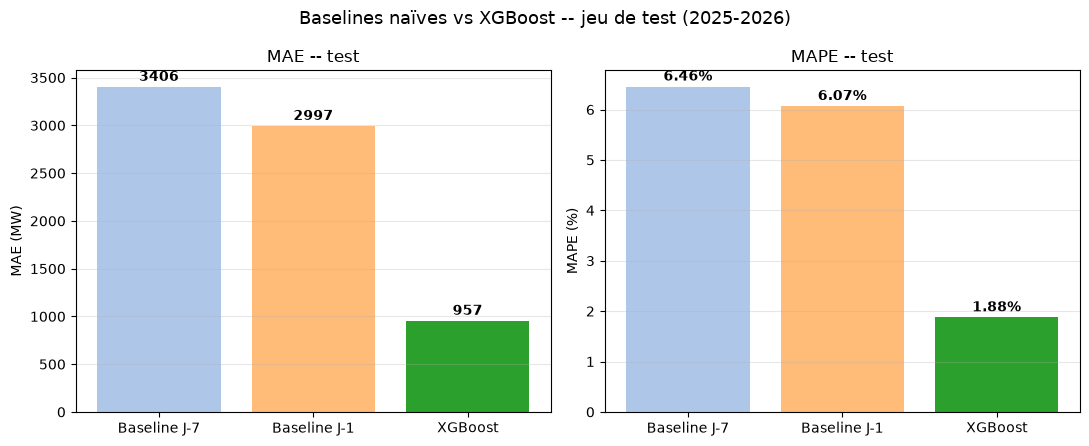

In [31]:
methodes = ["Baseline J-7", "Baseline J-1", "XGBoost"]
mae_valeurs = [mae_baseline_j7, mae_baseline_j1, resultats_test["mae"]]
mape_valeurs = [mape_baseline_j7, mape_baseline_j1, resultats_test["mape"]]
couleurs = ["#aec7e8", "#ffbb78", "#2ca02c"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

barres1 = ax1.bar(methodes, mae_valeurs, color=couleurs)
for barre, hauteur in zip(barres1, mae_valeurs):
    ax1.text(barre.get_x() + barre.get_width() / 2, hauteur + 60,
              f"{hauteur:.0f}", ha="center", fontweight="bold")
ax1.set_ylabel("MAE (MW)")
ax1.set_title("MAE -- test")
ax1.grid(axis="y", alpha=0.3)

barres2 = ax2.bar(methodes, mape_valeurs, color=couleurs)
for barre, hauteur in zip(barres2, mape_valeurs):
    ax2.text(barre.get_x() + barre.get_width() / 2, hauteur + 0.12,
              f"{hauteur:.2f}%", ha="center", fontweight="bold")
ax2.set_ylabel("MAPE (%)")
ax2.set_title("MAPE -- test")
ax2.grid(axis="y", alpha=0.3)

fig.suptitle("Baselines naïves vs XGBoost -- jeu de test (2025-2026)", fontsize=13)
plt.tight_layout()
plt.show()